# Decision Tree Classification

**Objective:** build a Decision Tree Classifier that decides whether to
play tennis, using the same dataset from the slides (slide 71), and
verify by hand that the tree is splitting on the feature with the
highest Information Gain (slides 48-56).

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

## The Dataset

14 days of weather, and whether tennis was played that day.

In [2]:
df = pd.DataFrame({
    'Outlook':     ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                     'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Humidity':    ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                     'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind':        ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
                     'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis':  ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                     'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No'],
})
df

,Outlook,Humidity,Wind,PlayTennis
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes
5,Rain,Normal,Strong,No
6,Overcast,Normal,Strong,Yes
7,Sunny,High,Weak,No
8,Sunny,Normal,Weak,Yes
9,Rain,Normal,Weak,Yes


## Step 1: Encode categorical features

Scikit-learn's `DecisionTreeClassifier` only accepts numeric input, so
we one-hot encode the feature columns with `pd.get_dummies`. The
label (`PlayTennis`) stays as-is - the classifier handles a
categorical target directly.

In [3]:
X = pd.get_dummies(df[['Outlook', 'Humidity', 'Wind']])
y = df['PlayTennis']
X

,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,False,False,True,True,False,False,True
1,False,False,True,True,False,True,False
2,True,False,False,True,False,False,True
3,False,True,False,True,False,False,True
4,False,True,False,False,True,False,True
5,False,True,False,False,True,True,False
6,True,False,False,False,True,True,False
7,False,False,True,True,False,False,True
8,False,False,True,False,True,False,True
9,False,True,False,False,True,False,True


## Step 2: Train the Decision Tree

We use `criterion='entropy'` so the split rule matches the entropy /
information gain formulas from the slides (a real project would
usually leave this as the default `'gini'`, which is faster to
compute and gives similar results).

In [4]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

## Step 3: Visualize the tree

Compare this to the flowchart-style diagram on slide 48 - internal
nodes are a feature test, branches are the decision rule, and leaves
are the outcome.

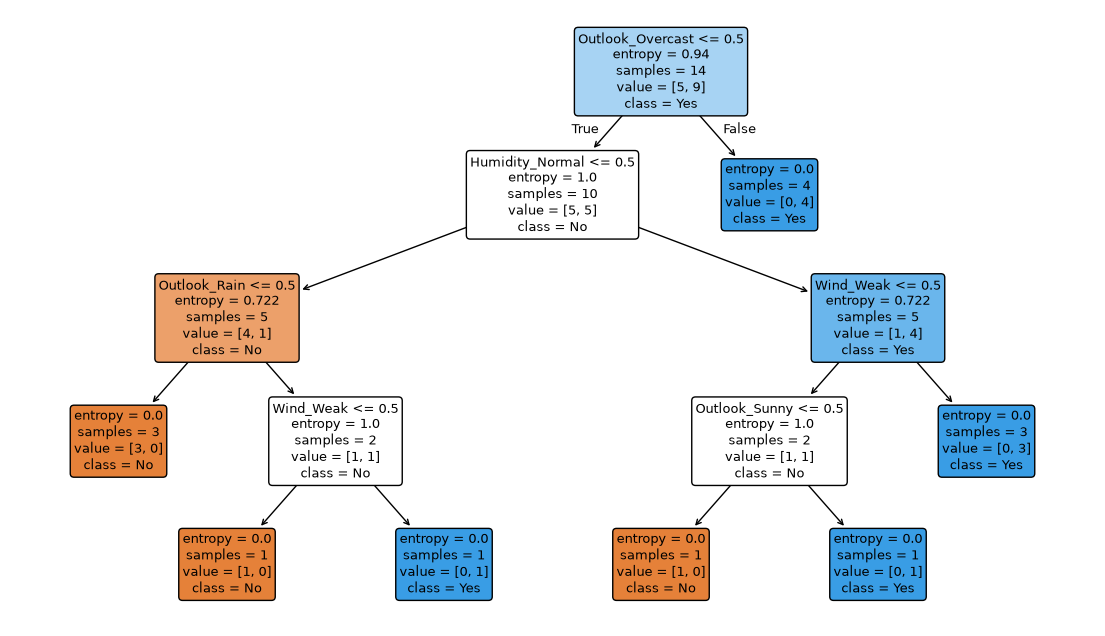

In [5]:
plt.figure(figsize=(14, 8))
plot_tree(model, feature_names=X.columns, class_names=model.classes_,
          filled=True, rounded=True, fontsize=9)
plt.show()

## Step 4: Verify Information Gain by hand

The slides walk through computing entropy and information gain for
splitting on `Outlook` (slides 50-56). Let's reproduce that
calculation in code and confirm it matches `Entropy(S) = 0.940` and
`Information Gain = 0.246` from slide 56.

In [6]:
import numpy as np

def entropy(labels):
    counts = labels.value_counts()
    probs = counts / len(labels)
    return -(probs * np.log2(probs)).sum() + 0.0  # +0.0 avoids a -0.0 display for pure groups

entropy_s = entropy(df['PlayTennis'])
print('Entropy(S):', round(entropy_s, 3))

Entropy(S): 0.94


In [7]:
weighted_entropy = 0
for value, group in df.groupby('Outlook'):
    weight = len(group) / len(df)
    e = entropy(group['PlayTennis'])
    weighted_entropy += weight * e
    print(f'Entropy(Outlook={value}): {round(e, 3)}  (n={len(group)})')

information_gain = entropy_s - weighted_entropy
print()
print('Weighted entropy after split on Outlook:', round(weighted_entropy, 3))
print('Information Gain:', round(information_gain, 3))

Entropy(Outlook=Overcast): 0.0  (n=4)
Entropy(Outlook=Rain): 0.971  (n=5)
Entropy(Outlook=Sunny): 0.971  (n=5)

Weighted entropy after split on Outlook: 0.694
Information Gain: 0.247


This matches the by-hand result on slide 56. `feature_importances_`
below is scikit-learn's own measure of how much each encoded feature
contributed to reducing impurity across the whole tree - the
`Outlook_*` columns should dominate, since `Outlook` was the root
split.

In [8]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

Wind_Weak           0.274205
Outlook_Overcast    0.240353
Humidity_Normal     0.211237
Outlook_Sunny       0.151929
Outlook_Rain        0.122276
Humidity_High       0.000000
Wind_Strong         0.000000
dtype: float64

## Step 5: Predict for a new day

Encode a new observation the same way as the training data, then
predict.

In [9]:
new_day = pd.DataFrame([{'Outlook': 'Sunny', 'Humidity': 'Normal', 'Wind': 'Weak'}])
new_day_encoded = pd.get_dummies(new_day).reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_day_encoded)
print('Play tennis?', prediction[0])

Play tennis? Yes


## Note: Random Forest

Slide 57 introduces the Random Forest Classifier as an "enhanced
version" of a single decision tree - it trains many trees (100 by
default) on random sub-samples of the data and lets them vote.
Swapping it in takes one line:

```python
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)
```